In [1]:
import spacy

In [2]:
# Cargar modelo en español
try:
    nlp = spacy.load("es_core_news_sm")
except OSError:
    print("Descargando modelo...")
    from spacy.cli import download
    download("es_core_news_sm")
    nlp = spacy.load("es_core_news_sm")

In [3]:
# Entrada de texto
with open("el_viejo_y_el_mar.txt", "r", encoding="utf-8") as f:
    texto_el_viejo_y_el_mar = f.read()

print(f"Texto cargado con éxito. Longitud: {len(texto_el_viejo_y_el_mar)} caracteres.")

Texto cargado con éxito. Longitud: 139879 caracteres.


In [4]:
# TOKENIZACIÓN
# Spacy procesa el texto y crea el objeto 'doc' lleno de metadatos
doc = nlp(texto_el_viejo_y_el_mar)

In [5]:
# Mostrar los primeros 15 tokens para entender cómo "ve" la máquina el texto
print(f"--- 1. Tokenización (Total tokens: {len(doc)}) ---")
print([token.text for token in doc][:20])

--- 1. Tokenización (Total tokens: 32338) ---
['El', 'Viejo', 'y', 'el', 'Mar', '\n', 'Por', '\n', 'Ernest', 'Hemingway', '\n\n\n', '---', 'FIN', 'DE', 'PÁGINA', '---', '\n\n', 'Era', 'un', 'viejo']


In [6]:
# FILTRADO DE STOP WORDS
# Separammos lo que aporta valor semántico del "pegamento" gramatical

tokens_relevantes = []
tokens_ruido = []

for token in doc:
    # Filtramos si es stop word o si es puntuación
    if not token.is_stop and not token.is_punct and token.text.strip():
        tokens_relevantes.append(token.text)
    elif token.is_stop:
        tokens_ruido.append(token.text)

print(f"\n--- 2. Filtrado de Stop Words ---")
print(f"Palabras eliminadas (Ruido): {tokens_ruido[:10]}...")
print(f"Palabras conservadas (Contenido): {tokens_relevantes[:10]}...")
print(f"Reducción de tamaño: de {len(doc)} a {len(tokens_relevantes)} tokens.")


--- 2. Filtrado de Stop Words ---
Palabras eliminadas (Ruido): ['El', 'y', 'el', 'Por', 'FIN', 'DE', 'Era', 'un', 'que', 'solo']...
Palabras conservadas (Contenido): ['Viejo', 'Mar', 'Ernest', 'Hemingway', 'PÁGINA', 'viejo', 'pescaba', 'bote', 'corriente', 'Golfo']...
Reducción de tamaño: de 32338 a 10038 tokens.


In [7]:
# LEMATIZACIÓN Y NORMALIZACIÓN FINAL
# Reducimos las palabras a su raíz (Lema) y estandarizamos a minúsculas
# Objetivo: Que "hablo", "hablaré" y "habla" cuenten como el mismo concepto: "hablar"

tokens_normalizados = []
cambios_interesantes = []

for token in doc:
    # Aplicamos los mismos filtros de cálidad que en el paso 2
    if not token.is_stop and not token.is_punct and token.text.strip():

        # 1. Extraer el lema (token.lemma_)
        # 2. Convertir a minúsculas (.lower())
        lema = token.lemma_.lower()
        tokens_normalizados.append(lema)

        # Para ejemplo de visualización. Guardamos casos donde la palabra cambió drásticamente
        # Ejemplo: "fui" -> "ir"
        if token.text.lower() != lema:
            cambios_interesantes.append(f"{token.text} - {lema}")

print(f"\n--- 3. Lematización y Normalización ---")
print(f"Total de tokens procesados: {len(tokens_normalizados)}")
print(f"Ejemplos de transformaciones (Palabra original ➡ Lema):")
# Mostramos solo los primeros 5 cambios para no saturar la pantalla
print(cambios_interesantes[:10]) 

print(f"\nResultado final (Primeros 10 tokens):")
print(tokens_normalizados[:20])


--- 3. Lematización y Normalización ---
Total de tokens procesados: 10038
Ejemplos de transformaciones (Palabra original ➡ Lema):
['pescaba - pescar', 'hacía - hacer', 'padres - padre', 'definitiva - definitivo', 'mala - malo', 'padres - padre', 'salido - salir', 'cogió - coger', 'peces - pez', 'Entristecía - entristecir']

Resultado final (Primeros 10 tokens):
['viejo', 'mar', 'ernest', 'hemingway', 'página', 'viejo', 'pescar', 'bote', 'corriente', 'golfo', 'hacer', 'ochenta', 'cogía', 'pez', 'cuarenta', 'muchacho', 'cuarenta', 'pescado', 'padre', 'muchacho']


In [8]:
corpus_lematizado = []

for oracion in doc.sents:
    lemas_oracion = [
        token.lemma_.lower()
        for token in oracion
        if not token.is_punct and not token.is_space and not token.is_stop
    ]
    if lemas_oracion:
        corpus_lematizado.append(" ".join(lemas_oracion))

print(f"Total de oraciones procesadas: {len(corpus_lematizado)}")

Total de oraciones procesadas: 1870


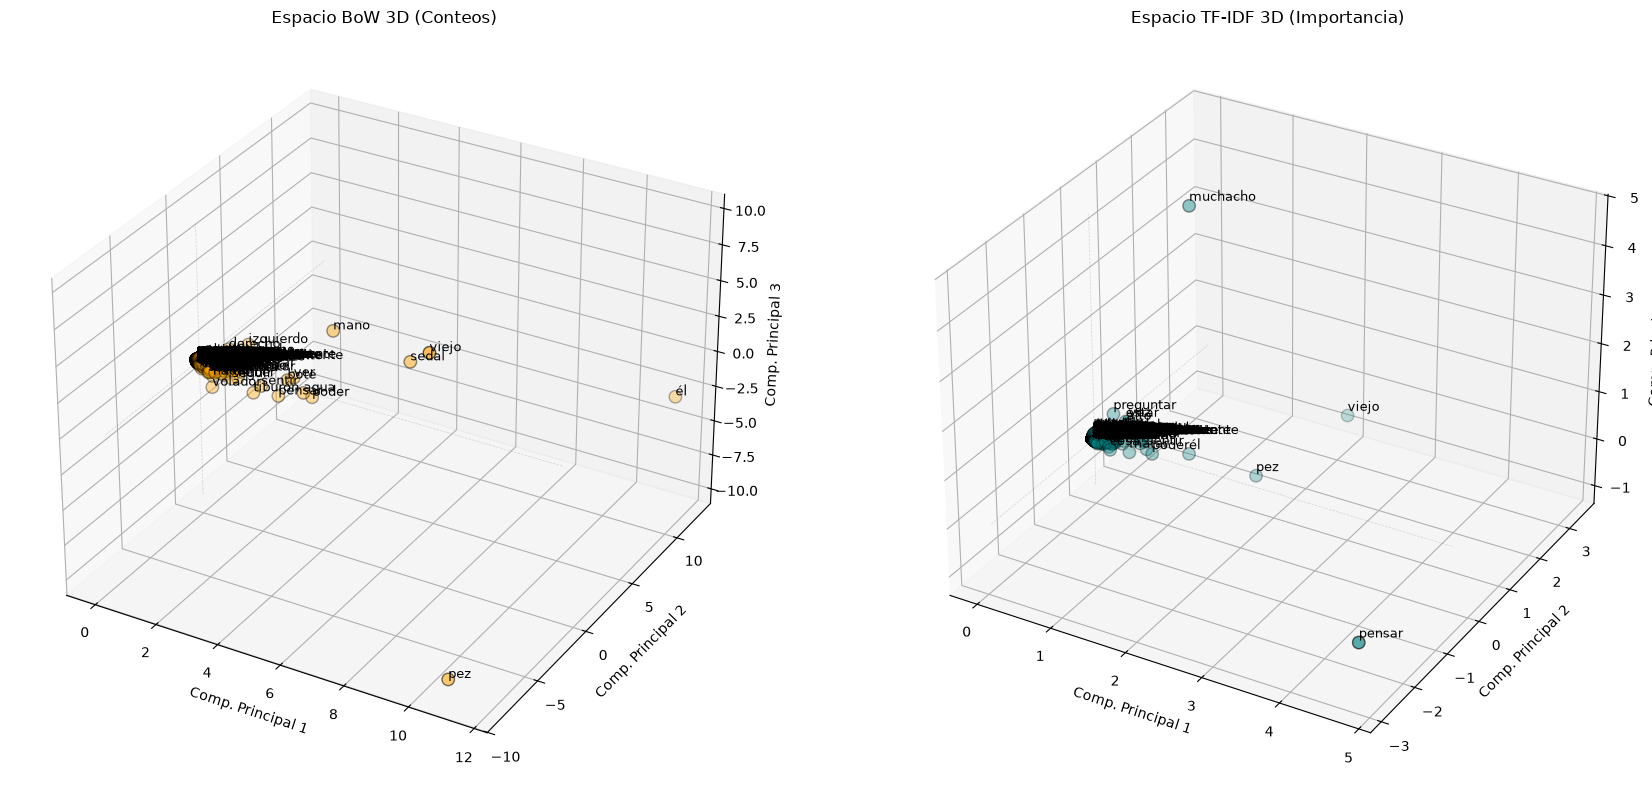

In [9]:
# ===== FEATURE EXTRACTION =====

import matplotlib.pyplot as plt
from utils.visualization_3d import graficar_palabras_3d
from utils.feature_extraction import extraer_caracteristicas_bow, extraer_caracteristicas_tfidf

# ---------------------------------------------------------
# EXTRACCIÓN DE DATOS PUROS DESDE UTILS
# ---------------------------------------------------------
# Obtenemos las matrices y vocabularios correspondientes
X_bow, vocab_bow = extraer_caracteristicas_bow(corpus_lematizado)
X_tfidf, vocab_tfidf = extraer_caracteristicas_tfidf(corpus_lematizado)

# ---------------------------------------------------------
# CONFIGURACIÓN Y RENDERIZADO DE LA FIGURA 3D
# ---------------------------------------------------------
# Creamos una figura ancha para poner dos gráficos lado a lado
fig = plt.figure(figsize=(18, 8))

# --- A. BAG OF WORDS (Izquierda) ---
ax1 = fig.add_subplot(121, projection='3d')
graficar_palabras_3d(ax1, X_bow, vocab_bow, 
                     "Espacio BoW 3D (Conteos)", 
                     "orange")

# --- B. TF-IDF (Derecha) ---
ax2 = fig.add_subplot(122, projection='3d')
graficar_palabras_3d(ax2, X_tfidf, vocab_tfidf, 
                     "Espacio TF-IDF 3D (Importancia)", 
                     "teal")

plt.tight_layout()
plt.show()

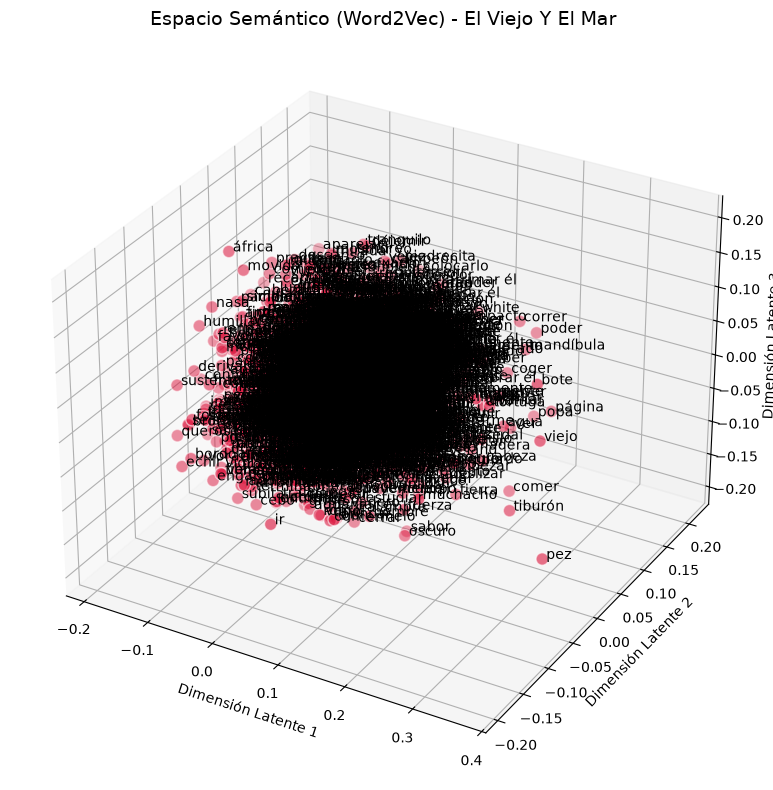


Semánticamente similares a 'poder':
  - comer él (0.9068)
  - coger (0.9016)
  - bajío (0.8850)


In [10]:
import matplotlib.pyplot as plt
from utils.feature_extraction import procesar_corpus_oraciones, entrenar_modelo_word2vec, aplicar_pca_embeddings
from utils.visualization_3d import graficar_espacio_semantico_3d

# Pipeline de procesamiento
oraciones = procesar_corpus_oraciones(nlp, texto_el_viejo_y_el_mar)
modelo_w2v = entrenar_modelo_word2vec(oraciones, dimensiones=10)
df_pca_3d = aplicar_pca_embeddings(modelo_w2v)

# ==========================================
# 3. VISUALIZACIÓN
# ==========================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

graficar_espacio_semantico_3d(ax, df_pca_3d, 'Espacio Semántico (Word2Vec) - El Viejo Y El Mar')

plt.tight_layout()
plt.show()

# ==========================================
# 4. EXPLORACIÓN INTERACTIVA
# ==========================================
def mostrar_similares(modelo, palabra):
    """Función auxiliar para exploración rápida en el notebook."""
    try:
        similares = modelo.wv.most_similar(palabra, topn=3)
        print(f"\nSemánticamente similares a '{palabra}':")
        for word, score in similares:
            print(f"  - {word} ({score:.4f})")
    except KeyError:
        print(f"\nLa palabra '{palabra}' no está en el vocabulario.")

# Pruebas semánticas
mostrar_similares(modelo_w2v, "poder")


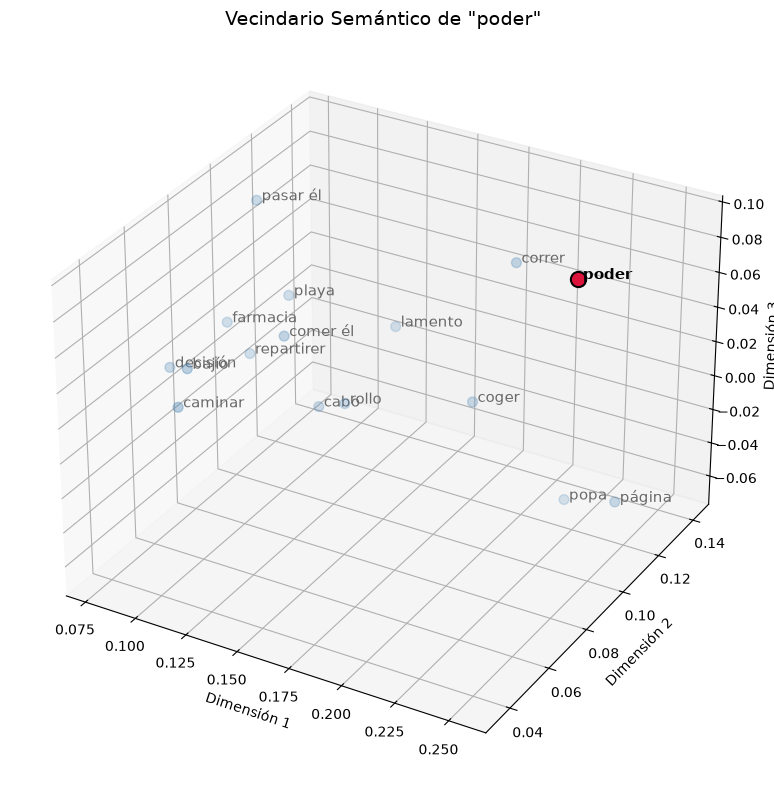

In [11]:
from utils.feature_extraction import obtener_vecindario_pca
from utils.visualization_3d import graficar_vecindario_3d

# 1. Asumiendo que modelo_w2v y df_pca_3d ya están generados en celdas anteriores...
palabra = "poder"

# 2. Extraer solo el vecindario de la palabra (los 15 más cercanos)
df_poder = obtener_vecindario_pca(modelo_w2v, df_pca_3d, palabra, top_n=15)

# 3. Visualizar
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

graficar_vecindario_3d(ax, df_poder, palabra, f'Vecindario Semántico de "{palabra}"')

plt.tight_layout()
plt.show()